<a href="https://colab.research.google.com/github/chomingi-25/2026_tues_bigdatacomputing_class/blob/main/%EC%A4%91%EA%B0%84%EA%B3%A0%EC%82%AC_%ED%94%84%EB%A1%9C%EA%B7%B8%EB%9E%98%EB%B0%8D_%EA%B3%BC%EC%A0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# [중간고사 실기 과제] 시계열 기상 데이터 통합 분석 파이프라인 구축
1. 과제 개요

  - 본 과제는 실무 데이터 분석 프로세스를 경험하기 위해 웹상의 기상 데이터를 수집하고, 이를 기계학습 모델링이 가능한 형태의 '깨끗한 데이터'로 가공하는 통합 분석 파이프라인을 개별 함수 단위로 구현하기.

2. 데이터 소스

  - URL: https://github.com/dongupak/DataML/raw/main/csv/weather.csv

  - 주요 컬럼: 지점, 일시, 평균기온, 최대풍속, 평균풍속

3. 핵심 요구 사항 (평가 기준)

  - 모듈화 설계:
    - 모든 기능은 독립적인 함수로 작성되어야 하고,
    - main() 함수에서 제어되어야 함.

  - 데이터 정규화 (Min-Max Scaling):
    - 특정 수치 데이터를 0과 1 사이로 변환하는 함수를 포함해야 함.

  - 시계열 핸들링:
    - 날짜 변환, 인덱스 설정 및 7일 이동 평균 추세선을 생성해야 함.

  - 데이터 재구조화:
    - pivot_table과 groupby를 활용하여 다차원적인 통계량을 산출해야 함.

  - 엑셀 내보내기 (To Excel):
    - 분석 결과인 전처리 데이터, 계절별 통계, 연도별 피벗 테이블을 하나의 엑셀 파일(weather_analysis_report.xlsx)의 별도 시트에 각각 저장해야 함.

  - 다음과 같은 데이터분석 그래프을 생성해야 함.
  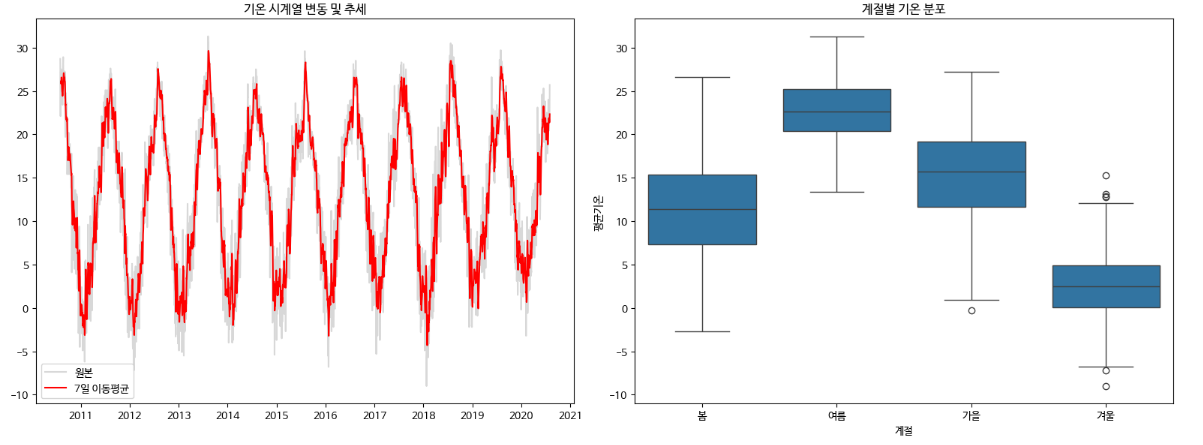

  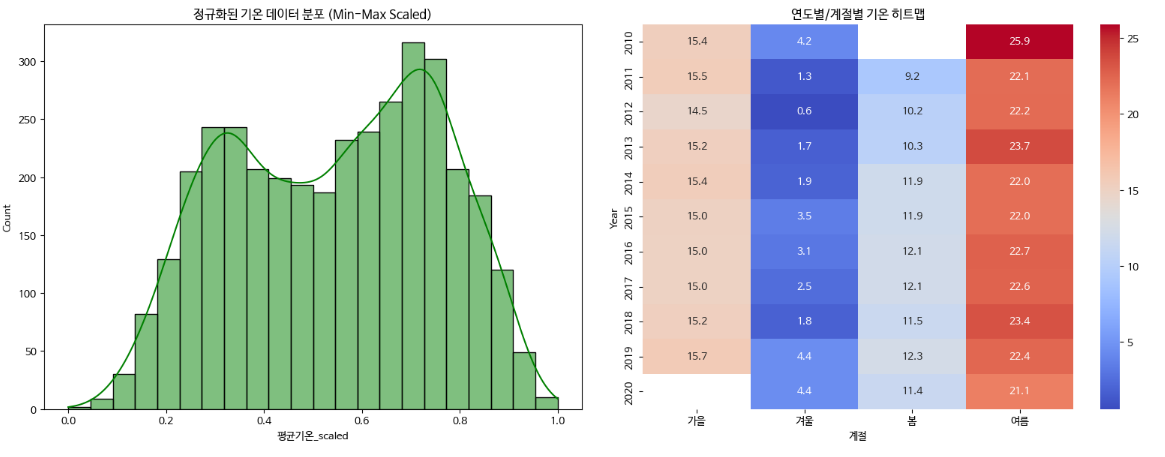



In [ ]:
!apt-get update -qq
!apt-get install -y fonts-nanum
!fc-cache -fv
!rm -rf /root/.cache/matplotlib

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 36 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 9s (1,168 kB/s)
Selecting previously unselected package fonts-nanum.
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
/usr/share/fonts: caching, new ca

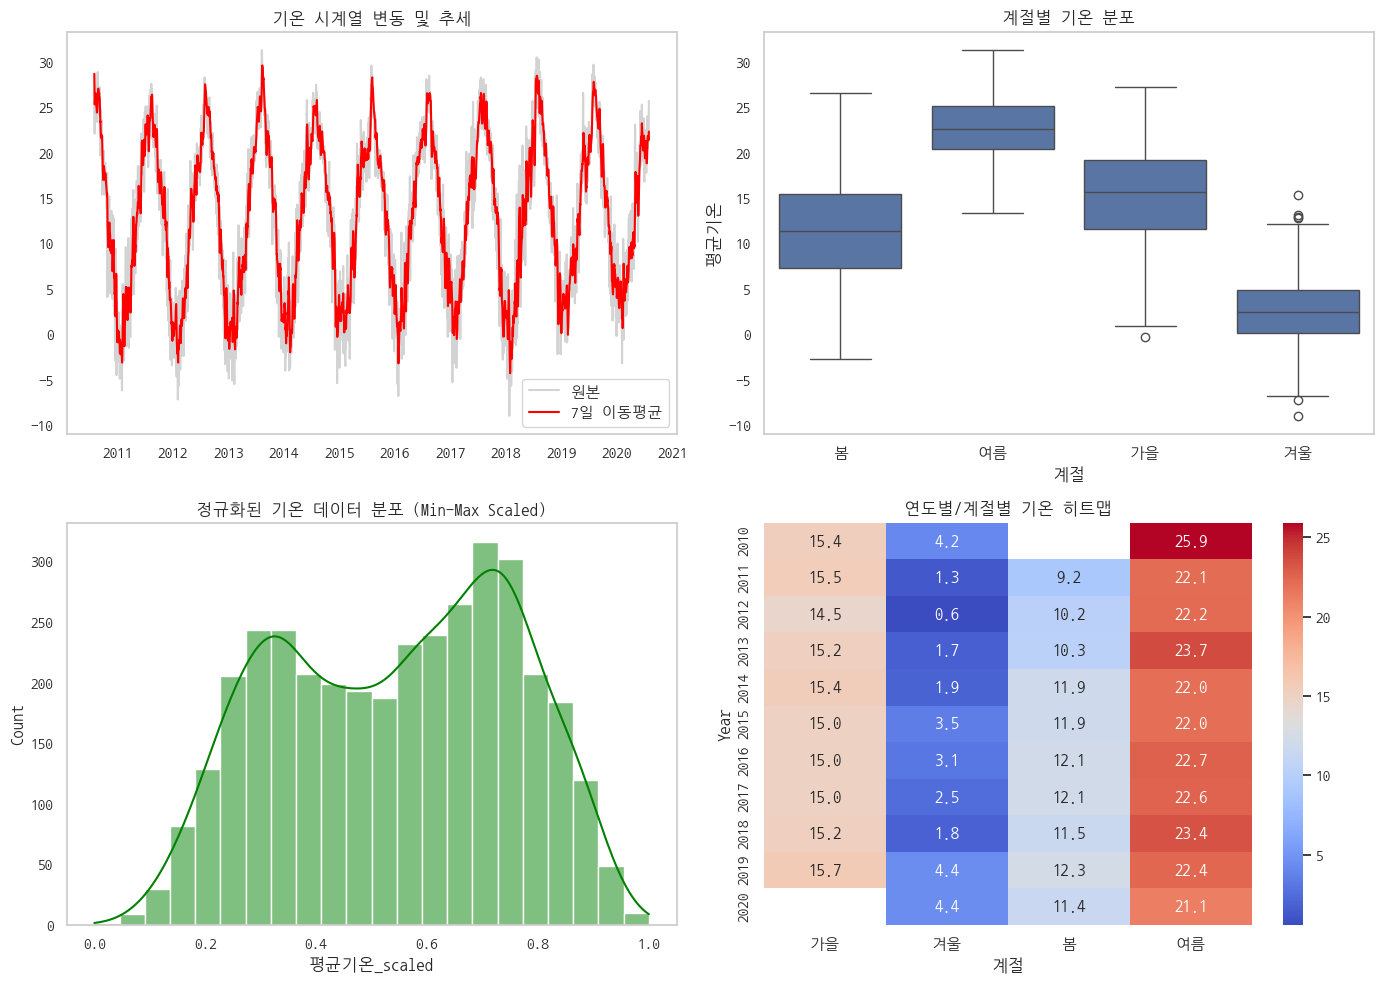

In [16]:
# 20251461 조민기

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import matplotlib.font_manager as fm
import requests
import warnings

# -------------------------------------------------------
# 1. 환경 설정
# -------------------------------------------------------
def set_environment():
    warnings.filterwarnings('ignore')
    sns.set(style='whitegrid')

#-------------------------------------------------------
# 2. (1) 한글 폰트 설정 (Redefined within this cell for scope)
#-------------------------------------------------------
def setup_korean_font():
  font_path = None

  for f in fm.findSystemFonts():
      if "NanumGothic" in f:
          font_path=f
          break

  if font_path is None:
      for f in fm.findSystemFonts():
          if "Nanum" in f:
             font_path=f
             break
  if font_path is None:
      print("❌ Nanum 폰트 없음")
      return
  fm.fontManager.addfont(font_path)
  font_name = fm.FontProperties(fname=font_path).get_name()

  plt.rcParams['font.family'] = font_name
  plt.rcParams['axes.unicode_minus'] = False

#-------------------------------------------------------
# 2. (2) 다운로드 함수
#-------------------------------------------------------
def download_weather_data(data_url, file_name):
    if not os.path.exists(file_name):
        response = requests.get(data_url)
        response.raise_for_status()
        with open(file_name, 'wb') as f:
            f.write(response.content)


#-------------------------------------------------------
# 3. CSV 불러오기
#-------------------------------------------------------
def load_weather_data(file_name):
  df=pd.read_csv(file_name, encoding='cp949')
  return df

#-------------------------------------------------------
# 4. Min-Max Scaling 함수
#-------------------------------------------------------

def min_max_scale(series):
  if series.min()==series.max():
    return series
  return (series-series.min())/(series.max()-series.min())

#-------------------------------------------------------
# 5. 계절 분류 함수
#-------------------------------------------------------
def get_season(month):
  if month in [3, 4, 5]:
    return '봄'
  elif month in [6, 7, 8]:
    return '여름'
  elif month in [9, 10, 11]:
    return '가을'
  elif month==12 or 1<=month<=2:
    return '겨울'

#-------------------------------------------------------
# 6. 데이터 전처리 함수(시계열 핸들링)
#-------------------------------------------------------
def preprocess_data(df):
  df['일시']=pd.to_datetime(df['일시'])
  df=df.set_index('일시')
  num_cols=['평균기온', '최대풍속', '평균풍속']
  df[num_cols]=df[num_cols].interpolate(method='linear')
  df['연도']=df.index.year
  df['월']=df.index.month
  df['계절']=df['월'].apply(get_season)
  df['평균기온_scaled']=min_max_scale(df['평균기온'])
  df['평균기온_7일이동평균']=df['평균기온'].rolling(window=7, min_periods=1).mean()
  return df

#--------------------------------------------------------
# 7. (1) 계절별 통계 - groupby()
#--------------------------------------------------------
def seasonal_statistics(df):
  season_order=['봄', '여름', '가을', '겨울']
  seasonal_stats=df.groupby('계절')[['평균기온', '최대풍속', '평균풍속']].agg(['mean', 'max', 'min'])
  seasonal_stats=seasonal_stats.reindex(season_order)
  return seasonal_stats

#--------------------------------------------------------
# 7. (2) 연도별/계절별 통계 -2) pivot_table()
#--------------------------------------------------------
def yearly_season_pivot(df):
  season_order=['봄', '여름', '가을', '겨울']
  pivot=pd.pivot_table(df, values='평균기온', index='연도', columns='계절',
                       aggfunc='mean')
  return pivot

#--------------------------------------------------------
# 8. 그래프 그리기
#--------------------------------------------------------
def set_graph_style(df, pivot):
  fig, ax=plt.subplots(2, 2, figsize=(14, 10))
  pivot_change=pivot.reindex(columns=['가을', '겨울', '봄', '여름'])
  plot_time_series(ax[0][0], df)
  plot_season(ax[0][1], df)
  plot_scaled_histogram(ax[1][0], df)
  plot_heatmap(ax[1][1], pivot_change)
  for a in ax.flatten():
    a.grid(False)
  plt.tight_layout()
  plt.show()

# (1) 시계열 데이터
def plot_time_series(ax, df):
  ax.plot(df.index, df['평균기온'], color='lightgray', label='원본')
  ax.plot(df.index, df['평균기온_7일이동평균'], color='red',
           label='7일 이동평균')
  ax.set_title('기온 시계열 변동 및 추세')
  ax.legend()

# (2) 계절별 기온을 boxplot() 함수로 표현
def plot_season(ax, df):
  season_order=['봄', '여름', '가을', '겨울']
  sns.boxplot(data=df, x='계절', y='평균기온', order=season_order, ax=ax)
  ax.set_title("계절별 기온 분포")
  ax.set_xlabel('계절')
  ax.set_ylabel('평균기온')

# (3) 정규화된 기온 데이터 히스토그램
def plot_scaled_histogram(ax, df):
  sns.histplot(df['평균기온_scaled'], bins=22, kde=True, kde_kws={'cut':0}, color='green', ax=ax)
  ax.set_title('정규화된 기온 데이터 분포 (Min-Max Scaled)')
  ax.set_xlabel('평균기온_scaled')
  ax.set_ylabel('Count')

# (4) 연도 및 계절별 기온 히트맵
def plot_heatmap(ax, pivot):
  sns.heatmap(pivot, annot=True, fmt='.1f', cmap='coolwarm', ax=ax)
  ax.set_title('연도별/계절별 기온 히트맵')
  ax.set_xlabel('계절')
  ax.set_ylabel('Year')

#--------------------------------------------------------
# 9. 엑셀 파일 저장
#--------------------------------------------------------
def save_to_excel(df, seasonal_stats, pivot):
  with pd.ExcelWriter('weather_analysis_report.xlsx', engine='openpyxl') as writer:
    df.to_excel(writer, sheet_name='전처리데이터')
    seasonal_stats.to_excel(writer, sheet_name='계절별통계')
    pivot.to_excel(writer, sheet_name='연도별피벗테이블')

#----------------------------------------------------
# 10. main()
#----------------------------------------------------
def main():
  set_environment()
  setup_korean_font()
  data_url = "https://github.com/dongupak/DataML/raw/main/csv/weather.csv"
  file_name = 'weather.csv'
  download_weather_data(data_url, file_name)

  df=load_weather_data(file_name)
  df=preprocess_data(df)
  seasonal_stats=seasonal_statistics(df)
  pivot=yearly_season_pivot(df)
  set_graph_style(df, pivot)
  save_to_excel(df, seasonal_stats, pivot)

#----------------------------------------------------
# 11. 프로그램 시작
#----------------------------------------------------
if __name__=='__main__':
  main()

# 위의 코드는 쳇 지피티 및 제미나이,
# 한글 폰트 설정 코드의 도움을 받아 작성되었으며,
# 쳇 지피티의 코드 및 주석에서 주석 및 표현을 변형시켰음을 알립니다.
# 출처 : 쳇 지피티, 제미나이